## Example

Document and describe the types present in the following function

In [6]:
sq2 = [1]

def squares(L : list) -> list:
    '''
    This is a function that takes as input a list of numbers and outputs
    a list of their squares.

    E.g.
    squares([1,2,3])
    >>> [1, 4, 9]

    squares([4.2,3.1,1.0])
    >>> [17.64, 9.610000000000001, 1.0]
    '''
    sq = []
    for i in L:
        sq += [i**2]
    return sq

In [8]:
sq2
sq

NameError: name 'sq' is not defined

In [3]:
print(squares([1,2,3]))
print(squares([4.2,3.1,1.0]))

[1, 4, 9]
[17.64, 9.610000000000001, 1.0]


In [5]:
help(squares)

Help on function squares in module __main__:

squares(L: list) -> list
    This is a function that takes as input a list of numbers and outputs
    a list of their squares.

    E.g.
    squares([1,2,3])
    >>> [1, 4, 9]

    squares([4.2,3.1,1.0])
    >>> [17.64, 9.610000000000001, 1.0]



## local and global variables

last time we discussed how the variable `sq` in the previous function is of a different kind from the other variables we saw so far in this course. For instance, the following code will give an error.

In [9]:
print(squares([1,2,3]))

[1, 4, 9]


In [ ]:
sq = [0]
squares([1,2,3])

# sq keeps the global value 
# it is unchanged by the value of sq inside of the function "squares"
print(sq)

[0]


This error comes from the fact that `sq` is a **local** variable that can only be called within the function `squares()`. The variables we saw earlier in this course are consequently called **global** variables. We can force a **local** variable to be **global** in the following way. However, this is *almost* always a very bad idea.

In [11]:
def squares(L : list[int]) -> list[int]:
    global sq
    sq = []
    for i in L:
        sq.append(i**2)
    return sq

In [13]:
squares([1,2,3])
print(sq)
print(sq[0])

[1, 4, 9]
1


## Documenting functions

You should always be as descriptive as possible when it comes to naming your functions. However, sometimes the name of a function alone will not be sufficient to explain to the user how the function ought to be used and why you wrote it. In  cases like these it is helpful to provide documentation. We can document functions in the followig way.

In [14]:
def squares(L : list[int]) -> list[int]:
    '''
    squares takes in a list of integers named `L`
    and returns a list of integers containing all
    of the squares of the entries in `L`.

    e.g. 
    >>> squares([1,2,3]) 
    [1,4,9]
    >>> squares([0,12])
    [0,144]
    '''
    squares = []
    for i in L:
        squares.append(i**2)
    return squares

Once we have documented our function, we can ask for help at any later point to see this documentation.

In [15]:
help(squares)

Help on function squares in module __main__:

squares(L: list[int]) -> list[int]
    squares takes in a list of integers named `L`
    and returns a list of integers containing all
    of the squares of the entries in `L`.

    e.g.
    >>> squares([1,2,3])
    [1,4,9]
    >>> squares([0,12])
    [0,144]



# Functions (part II)

In part I, we saw how functions can be used to reuse code, discussed arguments and return values.

The general definition of a function is something like:

``` 
def functionName(arg1: type1, arg2: type2, ...) -> returnType:
    '''
    documentation: at the very least, describe what the arguments 
    should be, what the return values are and how they are computed.
    This can span multiple lines
    '''
    <some python code here indented to the right of the 'def' statement>
    return <returnValue(s)>
```

Specifying the type of the arguments and return values (type hinting) is not technically mandatory 
but is considered good practice. We will systematically use type hints in this class.
Here is a list of standard python types and how they are to be used  for type hints:

### Basic types:
* `x: int = 1`
* `x: float = 1.0`
* `x: bool = True`
* `x: str = "test"`

### Containers:
* `x: list[int] = [1]`
* `x: set[int] = {6, 7}`
* `x: dict[str, float] = {"field": 2.0}`
*  tuples of fixed size
   `x: tuple[int, str, float] = (3, "yes", 7.5)`
* tuples of variable size
    `x: tuple[int, ...] = (1, 2, 3)`

### More advanced hints:
* use the `|` operator when something could be one of a few types `x: list[int | str] = [3, 5, "test", "fun"]`
* use `<X> | None` for something that could be of type `X` or nothing


In [16]:
# Going back to quadratic formula, the proper way to indicate types would be:
#
def quadraticSolve(a: float, b: float, c: float) -> tuple[float, float] | float | str:
    '''
    Compute the real roots of the quadratic equation ax^2 + bx + c = 0
    '''
    import math
    discriminant = b**2 - 4 * a * c
    if discriminant > 0:
        return (-b - math.sqrt(discriminant)) / 2 / a, (-b + math.sqrt(discriminant)) / 2 / a
    elif discriminant == 0:
        return -b / 2 / a
    else:
        return "This equation does not admit any real root"

roots = quadraticSolve(10,3,2)
print(roots)

This equation does not admit any real root


In [18]:
def dbl(a : int) -> int:
    '''
    dbl is a function that takes in an integer
    and returns its double (as an integer)
    '''
    return 2*a

print(dbl(2))
# Python ignores type hints
print(dbl('Hello world'))

4
Hello worldHello world


mypy

## Variable Scope
We saw that the arguments of a function only exist *inside* the function body. We say that the scope of the arguments is local to the function (or sometimes that they 'fall out of scope' outside of the function).

### Visibility and scope obey the following rules:
* The scope of any variable that is created *inside* a function is limited to the said function. We say that the variable is *local* to the function.

In [19]:
x = 12 # global
def example1(y: int):
    z = 23 #local variable
    # x is global, y and z are local
    print(f"inside example1: x = {x}, y = {y}, z = {z}")
example1(0)

inside example1: x = 12, y = 0, z = 23


* Any variable that is in the scope at the function call can be accessed but not modified. We say that these are *global* to the function
* If several variables with the same name exist, the one with the most local scope replaces the other ones.

In [20]:
x = 12 #global variable
def example2(y: int):
    x = 100 #local variable
    z = 23 #local variable
    # x is now local
    print(f"inside example2: x = {x}, y = {y}, z = {z}")
example2(0)
print(f"back in caller scope: x = {x}")

inside example2: x = 100, y = 0, z = 23
back in caller scope: x = 12


In [21]:
x = 12 # global
def example3(y: int):
    z = x # This implies that 'z' refers to a variable in the local context
    x = y # Global context variables cannot be modified
    print(f"inside example3: x = {x}, y = {y}, z = {z}")
example3(0)

UnboundLocalError: cannot access local variable 'x' where it is not associated with a value

In [23]:
x = 12
def example4(y: int):
    x = y # This implies that 'x' refers to a variable in the local context
    z = x 
    print(f"inside example4: x = {x}, y = {y}, z = {z}")
example4(0)
print(f"back in caller scope: x = {x}")

inside example4: x = 0, y = 0, z = 0
back in caller scope: x = 12


Things can get really complicated really quickly, for instance:

In [24]:
x = 1 # global value of x
y = 2 # global value of y
def f1():
    x = 12 #local value of x
    print(f'in f1: x = {x}, y = {y}')

def f2():
    y = 54 # local value of y
    print(f'in f2: x = {x}, y = {y}')
    f1()
f1()
f2()

in f1: x = 12, y = 2
in f2: x = 1, y = 54
in f1: x = 12, y = 2


The only way to maintain sanity is to avoid accessing global variables unless it is really impossible not to (which is very rare).
Instead, pass everything needed as arguments.

## Side effects

> "A function is said to have a *side effects* if it has any observable effect other than its primary effect of reading the value of its arguments and returning a value to the invoker of the operation."

* We have seen that a python function cannot change variables outside its scope (see `example2` above).
* It also cannot change the value of its arguments. (this makes sense, since we can pass *constants* as arguments).

Summary, anything that you want modified in a function needs to be `return`ed

In [ ]:
def f(x : float) -> float:
    print("some other stuff")
    y = 2
    y2 = 3
    y4 = 5
    for i in range(10000000000000):
        print(i)
    return x**2

In [26]:
f(2)

some other stuff


4

In [ ]:
x = 1 # global values
y = 2
def example5(x,z):
    x = z
    print(f"inside example5: x = {x}, y = {y}")
    return None

print(f"before example5: x = {x}, y = {y}")
example5(x,y)
print(f"after example5:  x = {x}, y = {y}")

### Warning: things get more complicated with containers...


In [27]:
L = [1,2,3]
M = L

L[0] = 5
print(f" M = {M}")
print(f"L = {L}")

 M = [5, 2, 3]
L = [5, 2, 3]


In [28]:
X = [1,2,3] # global values of X and Y
Y = [4,5,6]
def example6(Z : list) -> None:
    X[1] = Z[1]
    print(f"inside example6: X = {X}, Z = {Z}")
print(f"before example6: X = {X}, Y = {Y}")
example6(Y)
print(f"after example6:  X = {X}, Y = {Y}")

before example6: X = [1, 2, 3], Y = [4, 5, 6]
inside example6: X = [1, 5, 3], Z = [4, 5, 6]
after example6:  X = [1, 5, 3], Y = [4, 5, 6]


How come X was changed inside `example6`???

In [29]:
X = [1,2,3]
Y = [4,5,6]
def example7(Z):
    X = Z
    print(f"inside example7: X = {X}, Z = {Z}")
print(f"before example7: X = {X}, Y = {Y}")
example7(Y)
print(f"after example7:  X = {X}, Y = {Y}")

before example7: X = [1, 2, 3], Y = [4, 5, 6]
inside example7: X = [4, 5, 6], Z = [4, 5, 6]
after example7:  X = [1, 2, 3], Y = [4, 5, 6]


How come X was changed inside `example6` but not inside `example7`???

In [ ]:
def name(a,b):
    return a*a + b 

## lambda-functions
Lambdas are compact ways to define functions without necessarily giving them names. 

Syntax:
```
lambda arguments : expression
```

In [30]:
def evaluateat(f,x):
    print(f"f({x}) = {f(x)}")

g = lambda x : x**2

evaluateat(g,4)
evaluateat(g,5)

f(4) = 16
f(5) = 25


In [32]:
f = lambda x : x

f(2)
#f(-3)

2

say we just want to call `evaluateat` for $f(x) = x^2$ but will never really reuse $f$, so don't want to define this function. We can use a lambda here:

In [33]:
evaluateat(lambda x : x**2, 10)

f(10) = 100


In many languages lambda-functions are called *anonymous* functions as they do not automatically need a name. We can however, give them a name just like any other variable.

In [34]:
dbl = lambda x : 2*x
print(dbl(4))

8


A classical use of lambdas is to fix some parameters of a function.
The function $f(x) = |x|$ is not differentiable at 0. It is common to approximate by
$$
    f_\varepsilon(x) \ \sqrt{x^2+ \varepsilon},
$$
where $0 <\varepsilon$ is a small regularization parameter.

Let's compare the values of $f$ and $f_\varepsilon$.

In [35]:
import math
def smoothabs(a,epsilon):
    return math.sqrt(a**2+epsilon)

In [ ]:
%pip install matplotlib
%pip install ipympl

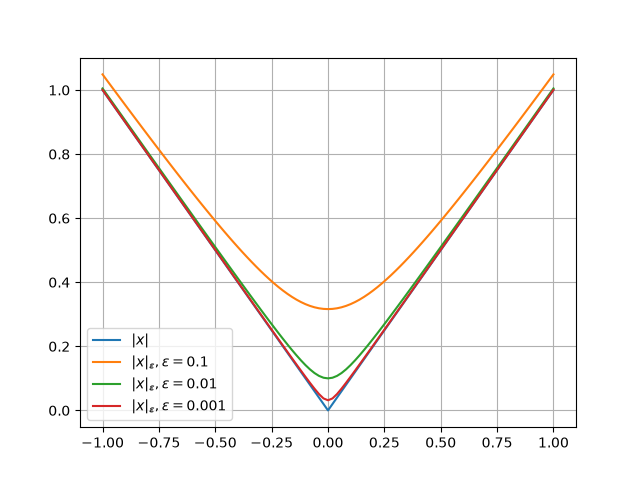

In [37]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
X = np.linspace(-1,1,101)

fig, ax = plt.subplots()
ax.plot(X,[abs(x) for x in X], label = f'$|x|$')
for epsilon in [0.1, 0.01, 0.001]:
    ax.plot(X,[smoothabs(x,epsilon) for x in X], label = f'$|x|_\\varepsilon, \\varepsilon = {{{epsilon}}}$')
ax.legend(loc=0)
ax.grid()

Another example: a function that 'tabulates' a mathematical function:

In [ ]:
def tabulate (x,f):
    print("x:    ", end="")
    for xx in x:
        print(f"{xx:.3f}", end = "\t")
    print()
    print("f(x): ", end="")
    for xx in x:
        print(f"{f(xx):.3f}", end = "\t")
    print()

tabulate([1.,2.,3., 4.5], lambda y : y**2)

x:    1.000	2.000	3.000	4.500	
f(x): 1.000	4.000	9.000	20.250	


In [39]:
# 
def deriv_f_at(f,a,h):
    '''
    function that takes in some
    function on floating points
    a point that is a floating point number
    and some small tolerance 
    and comptues the derivative at that point
    '''
    return (f(a+h)-f(a))/h

def f(x):
    return x**2

a = 2
print(deriv_f_at(f,2,1e-2))

4.009999999999891


In [41]:
f = lambda x : x**2

derivative = lambda f, a, h : (f(a+h)-f(a))/h

print(derivative(lambda x : x**2,2,1e-2))

4.009999999999891


In [42]:
X = [-1, -0.5, 0, 0.5, 1]
tabulate(X, lambda x: abs(x))
tabulate(X, lambda x : smoothabs(x, 0.001))

x:    -1.000	-0.500	0.000	0.500	1.000	
f(x): 1.000	0.500	0.000	0.500	1.000	
x:    -1.000	-0.500	0.000	0.500	1.000	
f(x): 1.000	0.501	0.032	0.501	1.000	


We can even write functions of many variables as lambda expressions. However, one should never use a lambda to create a reusable function, as a lambda function will come with no documentation.

In [ ]:

def derivate(f,a,h):
    '''
    Taking as input a function f and a point (floating point number) a
    computes the approximate derivative of f at h (using tolerance h) by
    the difference quotient method.
    '''
    return (f(a+h) - f(a))/h

derivate = lambda f, a, h : (f(a+h)- f(a))/h 

In [ ]:
tabulate(X,g)
tabulate(X, lambda x : derivate(g,x,0.001))